# RQ2: Profit Erosion Concentration & Customer Segmentation

This notebook implements **Research Question 2 (RQ2)** of the Capstone project:

> **To what extent is profit erosion concentrated among a small subset of customers, and can customers be meaningfully segmented based on behavioral and erosion characteristics?**

The analysis proceeds in two phases:
1. **Concentration analysis** (Pareto, Lorenz curve, Gini coefficient)
2. **Customer segmentation** using unsupervised learning (K-Means clustering)

**Note**: This notebook leverages functions from `src.rq2_run` to minimize code duplication and ensure consistency with the automated pipeline.

## 1. Setup and Imports

In [1]:
import json
import sys
import warnings
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('Cannot find project root containing src directory.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import project modules
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR
from src.data_processing import load_processed_data
from src.feature_engineering import (
    engineer_return_features,
    calculate_margins,
    engineer_customer_behavioral_features,
)

# Import from rq2_run module
from src.rq2_run import (
    build_customer_erosion,
    RQ2_OUT_DIR,
    RQ2_FIG_DIR,
)

# Import concentration and segmentation utilities
from src.rq2_concentration import (
    compute_pareto_table,
    lorenz_curve_points,
    gini_coefficient,
    top_x_customer_share_of_value,
    bootstrap_gini_p_value,
    get_business_summary,
)
from src.rq2_segmentation import (
    build_customer_segmentation_table,
    select_numeric_features,
    standardize_features,
    kmeans_fit_predict,
    elbow_inertia_over_k,
    silhouette_over_k,
    summarize_clusters,
    compute_clustering_quality_metrics,
)
from src.visualization import set_plot_style

# Setup directories
rq2_output_dir = RQ2_OUT_DIR
rq2_output_dir.mkdir(parents=True, exist_ok=True)

fig_dir = RQ2_FIG_DIR
fig_dir.mkdir(parents=True, exist_ok=True)

# Set plotting style
set_plot_style()

print(f'Project root: {project_root}')
print(f'Data outputs: {rq2_output_dir}')
print(f'Figure outputs: {fig_dir}')
print('Setup complete ✓')

Project root: c:\GitHub\unfc-capstone-project
Data outputs: c:\GitHub\unfc-capstone-project\data\processed\rq2
Figure outputs: c:\GitHub\unfc-capstone-project\figures\rq2
Setup complete ✓


## 2. Load and Prepare Data

**Data Requirements:**
- This notebook expects **processed data** from `data/processed/returns_eda_v1.parquet`
- The processed data should already contain:
  - `is_returned_item`, `is_returned_order` (return flags)
  - `item_margin`, `discount_pct` (margin calculations)
  - Price and cost columns

**If you get a KeyError about missing columns:**
- Run the data processing pipeline first: `python -m src.data_processing`
- Or ensure your data file has the required engineered features

We'll use the `build_customer_erosion()` function from `rq2_run.py` to create customer-level aggregations.

In [2]:
# Load processed item-level data
item_df = load_processed_data()
print(f'Loaded {len(item_df):,} item records')
print(f'Columns available: {len(item_df.columns)}')

# Check if return features already exist (they should in processed data)
if 'is_returned_item' not in item_df.columns:
    print('\n⚠ WARNING: Return features not found in processed data')
    print('\nThe processed data file needs to be regenerated with return features.')
    print('\nOptions to fix this:')
    print('  1. Run the data processing pipeline:')
    print('     python -m src.data_processing')
    print('\n  2. Or use the rq2_run.py script which handles this:')
    print('     python -m src.rq2_run')
    print('\n  3. Or continue in this notebook (we\'ll engineer features now)...')
    
    # Check if we have raw columns to engineer from
    if 'item_status' in item_df.columns and 'order_status' in item_df.columns:
        print('\n✓ Raw columns found - engineering return features now...')
        from src.feature_engineering import engineer_return_features
        item_df = engineer_return_features(item_df)
        print('✓ Return features engineered successfully')
    else:
        print('\n❌ ERROR: Neither processed features nor raw columns found')
        print('Available columns:', list(item_df.columns)[:10], '...')
        raise ValueError(
            'Cannot proceed: Data has neither is_returned_item nor item_status columns. '
            'Please run the data processing pipeline first.'
        )
else:
    print('✓ Return features already present in processed data')

print(f'\nReturn summary:')
print(f'  Total items: {len(item_df):,}')
print(f'  Returned items: {item_df["is_returned_item"].sum():,}')
print(f'  Return rate: {item_df["is_returned_item"].mean():.2%}')

Loaded 181,469 item records
Columns available: 46
✓ Return features already present in processed data

Return summary:
  Total items: 181,469
  Returned items: 18,026
  Return rate: 9.93%


## 3. Create Customer-Level Tables

### 3.1 Customer Behavioral Features

In [3]:
# Check if margin calculations already exist (they should in processed data)
if 'item_margin' in item_df.columns:
    print('✓ Margin calculations already present in processed data')
else:
    item_df = calculate_margins(item_df)
    print('Added margin calculations ✓')

# Add order_created_at if missing (proxy for recency calculations)
if 'order_created_at' not in item_df.columns:
    for col in ['item_created_at', 'item_shipped_at', 'item_delivered_at']:
        if col in item_df.columns:
            item_df['order_created_at'] = item_df[col]
            print(f'Using {col} as order_created_at proxy ✓')
            break
    else:
        item_df['order_created_at'] = pd.Timestamp.today()
        print('Using current date as order_created_at proxy ✓')
else:
    print('✓ Timestamp column already present')

# Build customer behavioral features (RFM-style metrics)
customer_behavior = engineer_customer_behavioral_features(item_df)

print(f'\nCustomer behavioral features created:')
print(f'  Total customers: {len(customer_behavior):,}')
print(f'  Features: {list(customer_behavior.columns)}')
print(f'\nSample:')
display(customer_behavior.head())

✓ Margin calculations already present in processed data
✓ Timestamp column already present

Customer behavioral features created:
  Total customers: 79,935
  Features: ['user_id', 'total_items', 'order_frequency', 'return_frequency', 'total_sales', 'total_margin', 'avg_item_price', 'avg_item_margin', 'customer_return_rate', 'avg_basket_size', 'purchase_recency_days', 'customer_tenure_days', 'avg_order_value']

Sample:


,user_id,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value
0,1,5,2,0,307.550000,141.411800,61.510000,28.28236,0.0,2.5,91.0,277.0,153.775000
1,10,1,1,0,59.000000,33.335000,59.000000,33.33500,0.0,1.0,94.0,2385.0,59.000000
2,100,5,2,0,316.960003,168.020902,63.392001,33.60418,0.0,2.5,90.0,1215.0,158.480001
3,1000,2,2,0,56.990000,32.382460,28.495000,16.19123,0.0,1.0,451.0,2399.0,28.495000
4,10000,3,2,0,195.020000,100.942080,65.006667,33.64736,0.0,1.5,896.0,2005.0,97.510000


### 3.2 Customer Profit Erosion Metrics

Using the `build_customer_erosion()` function from `rq2_run.py`:

In [4]:
# Build customer erosion table (uses rq2_run.build_customer_erosion)
customer_erosion = build_customer_erosion(item_df)

print(f'Customer erosion metrics:')
print(f'  Customers with returns: {len(customer_erosion):,}')
print(f'  Total profit erosion: ${customer_erosion["total_profit_erosion"].sum():,.2f}')
print(f'  Columns: {list(customer_erosion.columns)}')
print(f'\nSample:')
display(customer_erosion.head())

Customer erosion metrics:
  Customers with returns: 11,790
  Total profit erosion: $808,252.07
  Columns: ['user_id', 'total_orders', 'returned_items', 'total_margin_reversal', 'total_process_cost', 'total_profit_erosion', 'avg_erosion_per_return']

Sample:


,user_id,total_orders,returned_items,total_margin_reversal,total_process_cost,total_profit_erosion,avg_erosion_per_return
0,38929,1,4,666.809998,57.0,723.809998,180.952500
1,90574,2,5,641.914120,72.6,714.514120,142.902824
2,16299,1,4,639.041157,58.8,697.841157,174.460289
3,89510,1,4,604.945808,57.0,661.945808,165.486452
4,11692,1,4,585.446499,57.0,642.446499,160.611625


### 3.3 Save Intermediate Data

In [5]:
# Save customer-level tables
customer_behavior.to_csv(rq2_output_dir / 'customer_behavior.csv', index=False)
customer_erosion.to_csv(rq2_output_dir / 'customer_erosion.csv', index=False)

customer_behavior.to_parquet(rq2_output_dir / 'customer_behavior.parquet', index=False)
customer_erosion.to_parquet(rq2_output_dir / 'customer_erosion.parquet', index=False)

print('Customer-level tables saved ✓')

Customer-level tables saved ✓


## 4. Concentration Analysis

### 4.1 Compute Concentration Metrics

In [6]:
# Compute concentration metrics
pareto = compute_pareto_table(customer_erosion, value_col='total_profit_erosion')
lorenz = lorenz_curve_points(customer_erosion, value_col='total_profit_erosion')
gini = gini_coefficient(customer_erosion, value_col='total_profit_erosion')

# Compute top-x shares
top_10_share = top_x_customer_share_of_value(customer_erosion, x=0.10, value_col='total_profit_erosion')
top_20_share = top_x_customer_share_of_value(customer_erosion, x=0.20, value_col='total_profit_erosion')
top_50_share = top_x_customer_share_of_value(customer_erosion, x=0.50, value_col='total_profit_erosion')

print(f'Concentration Metrics:')
print(f'  Gini coefficient: {gini:.4f}')
print(f'  Top 10% of customers: {top_10_share:.1%} of total erosion')
print(f'  Top 20% of customers: {top_20_share:.1%} of total erosion')
print(f'  Top 50% of customers: {top_50_share:.1%} of total erosion')

Concentration Metrics:
  Gini coefficient: 0.4122
  Top 10% of customers: 30.3% of total erosion
  Top 20% of customers: 47.6% of total erosion
  Top 50% of customers: 78.2% of total erosion


### 4.2 Statistical Significance Test

In [7]:
# Bootstrap test: is observed concentration greater than uniform distribution?
gini_test = bootstrap_gini_p_value(
    customer_erosion,
    value_col='total_profit_erosion',
    n_bootstrap=1000,
    random_state=42
)

print('Bootstrap Gini Test Results:')
print(f'  Observed Gini: {gini_test["observed_gini"]:.4f}')
print(f'  Null Gini (mean): {gini_test["null_mean_gini"]:.4f}')
print(f'  P-value: {gini_test["p_value"]:.6f}')
print(f'  Significant: {"Yes" if gini_test["p_value"] < 0.05 else "No"}')

Bootstrap Gini Test Results:
  Observed Gini: 0.4122
  Null Gini (mean): -0.0000
  P-value: 0.000000
  Significant: Yes


### 4.3 Business Summary

In [8]:
# Get business-friendly summary
business_summary = get_business_summary(customer_erosion, value_col='total_profit_erosion')

print('Business Summary:')
for key, value in business_summary.items():
    print(f'  {key}: {value}')

Business Summary:
  gini_index: 0.412
  concentration_level: Moderate
  pareto_ratio: 20% of customers = 47.6% of loss
  recommendation: Broad Policy


### 4.4 Visualization: Pareto and Lorenz Curves

In [9]:
# Create 1x2 subplot for both curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pareto curve
axes[0].plot(pareto['customer_share'], pareto['value_share'], linewidth=2.5, color='steelblue')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='80% of erosion')
axes[0].axvline(x=0.2, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='20% of customers')
axes[0].set_xlabel('Cumulative Share of Customers', fontsize=12)
axes[0].set_ylabel('Cumulative Share of Profit Erosion', fontsize=12)
axes[0].set_title('Pareto Curve: Profit Erosion Concentration', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Lorenz curve
axes[1].plot(lorenz['population_share'], lorenz['value_share'], linewidth=2.5, 
             color='coral', label='Lorenz curve')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Perfect equality')
# Fill area between Lorenz curve and perfect equality line
axes[1].fill_between(lorenz['population_share'], lorenz['value_share'], 
                      lorenz['population_share'], alpha=0.2, color='coral')
axes[1].set_xlabel('Cumulative Share of Customers', fontsize=12)
axes[1].set_ylabel('Cumulative Share of Profit Erosion', fontsize=12)
axes[1].set_title(f'Lorenz Curve (Gini = {gini:.4f})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / 'concentration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Concentration curves saved to {fig_dir / "concentration_curves.png"}')

Concentration curves saved to c:\GitHub\unfc-capstone-project\figures\rq2\concentration_curves.png


### 4.5 Save Concentration Results

In [10]:
# Save tables
pareto.to_csv(rq2_output_dir / 'pareto_table.csv', index=False)
lorenz.to_csv(rq2_output_dir / 'lorenz_points.csv', index=False)

# Save summary
concentration_summary = {
    'gini_coefficient': float(gini),
    'top_10_pct_share': float(top_10_share),
    'top_20_pct_share': float(top_20_share),
    'top_50_pct_share': float(top_50_share),
    'total_customers': int(len(customer_erosion)),
    'total_erosion': float(customer_erosion['total_profit_erosion'].sum()),
    'gini_bootstrap_test': gini_test,
    'business_summary': business_summary,
}

with open(rq2_output_dir / 'concentration_summary.json', 'w') as f:
    json.dump(concentration_summary, f, indent=2)

print('Concentration results saved ✓')

Concentration results saved ✓


## 5. Customer Segmentation

### 5.1 Build Segmentation Table

In [11]:
# Merge behavioral and erosion features
segmentation_table = build_customer_segmentation_table(
    customer_behavior,
    customer_erosion,
    id_col='user_id'
)

print(f'Segmentation table created:')
print(f'  Customers: {len(segmentation_table):,}')
print(f'  Features: {len(segmentation_table.columns)}')
print(f'\nSample:')
display(segmentation_table.head())

Segmentation table created:
  Customers: 79,935
  Features: 19

Sample:


,user_id,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value,total_orders,returned_items,total_margin_reversal,total_process_cost,total_profit_erosion,avg_erosion_per_return
0,1,5,2,0,307.550000,141.411800,61.510000,28.28236,0.0,2.5,91.0,277.0,153.775000,0.0,0.0,0.0,0.0,0.0,0.0
1,10,1,1,0,59.000000,33.335000,59.000000,33.33500,0.0,1.0,94.0,2385.0,59.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,100,5,2,0,316.960003,168.020902,63.392001,33.60418,0.0,2.5,90.0,1215.0,158.480001,0.0,0.0,0.0,0.0,0.0,0.0
3,1000,2,2,0,56.990000,32.382460,28.495000,16.19123,0.0,1.0,451.0,2399.0,28.495000,0.0,0.0,0.0,0.0,0.0,0.0
4,10000,3,2,0,195.020000,100.942080,65.006667,33.64736,0.0,1.5,896.0,2005.0,97.510000,0.0,0.0,0.0,0.0,0.0,0.0


### 5.2 Feature Selection and Standardization

In [12]:
# Select features (excluding leakage features like total_profit_erosion)
X_df, feature_cols = select_numeric_features(
    segmentation_table,
    id_col='user_id',
    feature_cols=None,  # Use default behavioral features
    exclude_leakage_features=True
)

print(f'Features selected for clustering ({len(feature_cols)}):')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i}. {col}')

# Standardize features (Z-score normalization)
X_scaled = standardize_features(X_df)
print(f'\nFeatures standardized: {X_scaled.shape}')

Features selected for clustering (8):
  1. avg_order_value
  2. avg_basket_size
  3. order_frequency
  4. customer_return_rate
  5. customer_tenure_days
  6. purchase_recency_days
  7. total_sales
  8. total_margin

Features standardized: (79935, 8)


### 5.3 Determine Optimal k

#### Elbow Method and Silhouette Analysis

**Performance Optimization**: For large datasets (>10k customers), we use sampling for silhouette computation to reduce runtime from ~10 minutes to ~30 seconds while maintaining representative results.

In [13]:
# Compute both elbow and silhouette diagnostics
# Note: Using smaller k range (2-8) for faster computation
k_range_elbow = list(range(1, 9))  # Reduced from 11 to 9
k_range_sil = list(range(2, 9))    # Reduced from 11 to 9

print('Computing elbow curve...')
elbow_df = elbow_inertia_over_k(X_scaled, k_list=k_range_elbow, random_state=42)
print('✓ Elbow curve complete')

# For large datasets (>10k samples), use sampling for silhouette analysis
if len(X_scaled) > 10000:
    print(f'Large dataset detected ({len(X_scaled):,} samples)')
    print('Using stratified sampling (5,000 samples) for faster silhouette computation...')
    # Sample 5000 points for silhouette (much faster, still representative)
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_idx]
    silhouette_df = silhouette_over_k(X_sample, k_list=k_range_sil, random_state=42)
else:
    print('Computing silhouette scores...')
    silhouette_df = silhouette_over_k(X_scaled, k_list=k_range_sil, random_state=42)
print('✓ Silhouette analysis complete')

# Find optimal k (highest silhouette score)
optimal_k = int(silhouette_df.sort_values(
    ['silhouette', 'k'],
    ascending=[False, True]
).iloc[0]['k'])

print(f'Optimal k by silhouette score: {optimal_k}')
print(f'\nSilhouette scores:')
display(silhouette_df)

# Create 1x2 subplot for diagnostics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow curve
axes[0].plot(elbow_df['k'], elbow_df['inertia'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method: Optimal k Selection', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(silhouette_df['k'], silhouette_df['silhouette'], marker='o', linewidth=2, 
             markersize=8, color='coral')
axes[1].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6, 
                label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis: Optimal k Selection', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / 'clustering_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Clustering diagnostics saved to {fig_dir / "clustering_diagnostics.png"}')

Computing elbow curve...
✓ Elbow curve complete
Large dataset detected (79,935 samples)
Using stratified sampling (5,000 samples) for faster silhouette computation...
✓ Silhouette analysis complete
Optimal k by silhouette score: 2

Silhouette scores:


,k,silhouette
0,2,0.344922
1,3,0.329207
2,4,0.246548
3,5,0.266708
4,6,0.276330
5,7,0.235448
6,8,0.236297


Clustering diagnostics saved to c:\GitHub\unfc-capstone-project\figures\rq2\clustering_diagnostics.png


### 5.4 Apply K-Means Clustering

In [14]:
# Apply K-Means with optimal k
cluster_labels = kmeans_fit_predict(X_scaled, k=optimal_k, random_state=42)

# Add cluster labels to segmentation table
segmentation_table['cluster'] = cluster_labels

print(f'K-Means clustering applied with k={optimal_k}')
print(f'\nCluster distribution:')
cluster_counts = segmentation_table['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(segmentation_table) * 100
    print(f'  Cluster {cluster_id}: {count:,} customers ({pct:.1f}%)')

K-Means clustering applied with k=2

Cluster distribution:
  Cluster 0: 59,599 customers (74.6%)
  Cluster 1: 20,336 customers (25.4%)


### 5.5 Clustering Quality Metrics

In [15]:
# Compute clustering quality metrics
# For large datasets, use sampling for faster silhouette computation
if len(X_scaled) > 10000:
    print(f'Using sampling ({min(5000, len(X_scaled)):,} samples) for quality metrics...')
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_idx]
    labels_sample = cluster_labels[sample_idx]
    quality_metrics = compute_clustering_quality_metrics(X_sample, labels_sample)
else:
    quality_metrics = compute_clustering_quality_metrics(X_scaled, cluster_labels)

print('Clustering Quality Metrics:')
for metric, value in quality_metrics.items():
    print(f'  {metric}: {value:.4f}')

Using sampling (5,000 samples) for quality metrics...
Clustering Quality Metrics:
  silhouette: 0.3393
  calinski_harabasz: 1697.4854
  davies_bouldin: 1.4812


### 5.6 Cluster Profiling

In [16]:
# Summarize clusters by profit erosion
cluster_summary = summarize_clusters(
    segmentation_table,
    value_col='total_profit_erosion',
    cluster_col='cluster'
)

print('Cluster Summary by Profit Erosion:')
display(cluster_summary)

# Detailed cluster profiles (all features)
print('\nDetailed Cluster Profiles (Mean Values):')
cluster_profiles = segmentation_table.groupby('cluster')[feature_cols].mean().round(2)
display(cluster_profiles.T)  # Transpose for better readability

Cluster Summary by Profit Erosion:


,cluster,Count,Total_Erosion,Mean_Erosion,Median_Erosion
0,0,59599,353275.38,5.93,0.0
1,1,20336,454976.69,22.37,0.0



Detailed Cluster Profiles (Mean Values):


cluster,0,1
avg_order_value,57.74,171.97
avg_basket_size,1.24,2.08
order_frequency,1.32,2.27
customer_return_rate,0.10,0.10
customer_tenure_days,1262.22,1229.14
purchase_recency_days,572.23,413.38
total_sales,73.93,317.14
total_margin,37.77,166.74


### 5.7 Cluster Visualization

In [17]:
# Visualize clusters by key metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total profit erosion by cluster
cluster_erosion = segmentation_table.groupby('cluster')['total_profit_erosion'].sum().sort_values(ascending=False)
colors_erosion = plt.cm.Reds(np.linspace(0.4, 0.9, len(cluster_erosion)))
axes[0, 0].bar(cluster_erosion.index.astype(str), cluster_erosion.values, color=colors_erosion, edgecolor='black')
axes[0, 0].set_xlabel('Cluster', fontsize=11)
axes[0, 0].set_ylabel('Total Profit Erosion ($)', fontsize=11)
axes[0, 0].set_title('Total Profit Erosion by Cluster', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(cluster_erosion.items()):
    axes[0, 0].text(i, val, f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

# Cluster sizes
cluster_sizes = segmentation_table['cluster'].value_counts().sort_index()
colors_sizes = plt.cm.Blues(np.linspace(0.4, 0.9, len(cluster_sizes)))
axes[0, 1].bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors_sizes, edgecolor='black')
axes[0, 1].set_xlabel('Cluster', fontsize=11)
axes[0, 1].set_ylabel('Number of Customers', fontsize=11)
axes[0, 1].set_title('Cluster Sizes', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(cluster_sizes.items()):
    pct = val / len(segmentation_table) * 100
    axes[0, 1].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Average profit erosion by cluster
avg_erosion = segmentation_table.groupby('cluster')['total_profit_erosion'].mean().sort_values(ascending=False)
colors_avg = plt.cm.Oranges(np.linspace(0.4, 0.9, len(avg_erosion)))
axes[1, 0].bar(avg_erosion.index.astype(str), avg_erosion.values, color=colors_avg, edgecolor='black')
axes[1, 0].set_xlabel('Cluster', fontsize=11)
axes[1, 0].set_ylabel('Average Profit Erosion ($)', fontsize=11)
axes[1, 0].set_title('Average Profit Erosion per Customer', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(avg_erosion.items()):
    axes[1, 0].text(i, val, f'${val:.2f}', ha='center', va='bottom', fontsize=9)

# Return rate by cluster
if 'customer_return_rate' in segmentation_table.columns:
    avg_return_rate = segmentation_table.groupby('cluster')['customer_return_rate'].mean().sort_values(ascending=False)
    colors_rr = plt.cm.Purples(np.linspace(0.4, 0.9, len(avg_return_rate)))
    axes[1, 1].bar(avg_return_rate.index.astype(str), avg_return_rate.values * 100, color=colors_rr, edgecolor='black')
    axes[1, 1].set_xlabel('Cluster', fontsize=11)
    axes[1, 1].set_ylabel('Average Return Rate (%)', fontsize=11)
    axes[1, 1].set_title('Average Return Rate by Cluster', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, (idx, val) in enumerate(avg_return_rate.items()):
        axes[1, 1].text(i, val * 100, f'{val * 100:.1f}%', ha='center', va='bottom', fontsize=9)
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(fig_dir / 'cluster_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Cluster visualizations saved to {fig_dir / "cluster_profiles.png"}')

Cluster visualizations saved to c:\GitHub\unfc-capstone-project\figures\rq2\cluster_profiles.png


### 5.8 Statistical Significance Testing

**Effect Size Calculation:**
- **ANOVA (parametric)**: Uses Eta-squared (η²) based on sums of squares
- **Kruskal-Wallis (non-parametric)**: Uses Epsilon-squared (ε²) based on the H statistic

Both metrics quantify the proportion of variance explained by cluster membership and use the same interpretation thresholds.

In [18]:
# Test if clusters differ significantly in profit erosion
cluster_groups = [
    segmentation_table[segmentation_table['cluster'] == c]['total_profit_erosion'].values
    for c in sorted(segmentation_table['cluster'].unique())
]

# Normality tests
normality_pvals = []
for i, group in enumerate(cluster_groups):
    if len(group) < 3:
        p = 0.0
    elif len(group) > 5000:
        sample = np.random.default_rng(42).choice(group, size=5000, replace=False)
        p = stats.shapiro(sample)[1]
    else:
        p = stats.shapiro(group)[1]
    normality_pvals.append(p)

all_normal = all(p > 0.05 for p in normality_pvals)

# Choose test based on normality
if all_normal:
    stat, p_value = stats.f_oneway(*cluster_groups)
    test_name = 'One-way ANOVA'
    
    # Effect size: Eta-squared for ANOVA
    all_erosion = segmentation_table['total_profit_erosion'].values
    grand_mean = all_erosion.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in cluster_groups)
    ss_total = np.sum((all_erosion - grand_mean)**2)
    effect_size = ss_between / ss_total if ss_total > 0 else 0.0
    effect_metric = 'Eta-squared (η²)'
else:
    stat, p_value = stats.kruskal(*cluster_groups)
    test_name = 'Kruskal-Wallis'
    
    # Effect size: Epsilon-squared (ε²) for Kruskal-Wallis
    # Formula: ε² = (H - k + 1) / (n - k)
    # where H = Kruskal-Wallis statistic, k = number of groups, n = total sample size
    n_total = len(segmentation_table)
    k_groups = len(cluster_groups)
    effect_size = (stat - k_groups + 1) / (n_total - k_groups)
    effect_size = max(0.0, effect_size)  # Ensure non-negative
    effect_metric = 'Epsilon-squared (ε²)'

print(f'Statistical Test: {test_name}')
print(f'  Test statistic: {stat:.4f}')
print(f'  P-value: {p_value:.6f}')
print(f'  Significant: {"Yes (p < 0.05)" if p_value < 0.05 else "No (p >= 0.05)"}')

# Interpret effect size (same thresholds for both metrics)
if effect_size < 0.01:
    effect_interpretation = 'Negligible'
elif effect_size < 0.06:
    effect_interpretation = 'Small'
elif effect_size < 0.14:
    effect_interpretation = 'Medium'
else:
    effect_interpretation = 'Large'

print(f'\nEffect Size:')
print(f'  {effect_metric}: {effect_size:.4f} ({effect_interpretation})')
print(f'  Variance explained: {effect_size * 100:.2f}%')

Statistical Test: Kruskal-Wallis
  Test statistic: 1057.4138
  P-value: 0.000000
  Significant: Yes (p < 0.05)

Effect Size:
  Epsilon-squared (ε²): 0.0132 (Small)
  Variance explained: 1.32%


### 5.9 Post-hoc Pairwise Comparisons

In [19]:
# Post-hoc pairwise comparisons (if omnibus test is significant)
if p_value < 0.05 and len(cluster_groups) > 2:
    cluster_ids = sorted(segmentation_table['cluster'].unique())
    n_comparisons = len(list(combinations(cluster_ids, 2)))
    bonferroni_alpha = 0.05 / n_comparisons
    
    posthoc_results = []
    for c1, c2 in combinations(cluster_ids, 2):
        group1 = segmentation_table[segmentation_table['cluster'] == c1]['total_profit_erosion'].values
        group2 = segmentation_table[segmentation_table['cluster'] == c2]['total_profit_erosion'].values
        
        if all_normal:
            pair_stat, pair_p = ttest_ind(group1, group2, equal_var=False)
            pair_test = 't-test'
        else:
            pair_stat, pair_p = mannwhitneyu(group1, group2, alternative='two-sided')
            pair_test = 'Mann-Whitney U'
        
        # Cohen's d effect size
        mean1, mean2 = group1.mean(), group2.mean()
        std_pooled = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
        cohens_d = (mean1 - mean2) / std_pooled if std_pooled > 0 else 0.0
        
        posthoc_results.append({
            'cluster_1': int(c1),
            'cluster_2': int(c2),
            'test': pair_test,
            'statistic': float(pair_stat),
            'p_value': float(pair_p),
            'bonferroni_alpha': float(bonferroni_alpha),
            'significant': bool(pair_p < bonferroni_alpha),
            'cohens_d': float(cohens_d),
            'mean_diff': float(mean1 - mean2),
        })
    
    posthoc_df = pd.DataFrame(posthoc_results)
    print(f'\nPost-hoc Pairwise Comparisons (Bonferroni α={bonferroni_alpha:.6f}):')
    display(posthoc_df)
    
    posthoc_df.to_csv(rq2_output_dir / 'posthoc_tests.csv', index=False)
    print(f'\nPost-hoc results saved to {rq2_output_dir / "posthoc_tests.csv"}')
else:
    print('\nPost-hoc testing skipped (non-significant omnibus test or ≤2 clusters)')
    posthoc_df = pd.DataFrame()


Post-hoc testing skipped (non-significant omnibus test or ≤2 clusters)


### 5.10 Save Segmentation Results

In [20]:
# Save clustered customers
segmentation_table.to_csv(rq2_output_dir / 'clustered_customers.csv', index=False)
segmentation_table.to_parquet(rq2_output_dir / 'clustered_customers.parquet', index=False)

# Save cluster summary
cluster_summary.to_csv(rq2_output_dir / 'cluster_summary.csv', index=False)

# Save diagnostic tables
elbow_df.to_csv(rq2_output_dir / 'elbow_inertia.csv', index=False)
silhouette_df.to_csv(rq2_output_dir / 'silhouette_scores.csv', index=False)

# Save comprehensive summary
segmentation_summary = {
    'k_final': int(optimal_k),
    'selection_method': 'silhouette_score',
    'features_used': feature_cols,
    'quality_metrics': quality_metrics,
    'cluster_sizes': segmentation_table['cluster'].value_counts().sort_index().to_dict(),
    'statistical_test': {
        'test_name': test_name,
        'statistic': float(stat),
        'p_value': float(p_value),
        'is_significant': bool(p_value < 0.05),
        'effect_size': float(effect_size),
        'effect_metric': effect_metric,
        'effect_interpretation': effect_interpretation,
    },
}

with open(rq2_output_dir / 'segmentation_summary.json', 'w') as f:
    json.dump(segmentation_summary, f, indent=2)

print('Segmentation results saved ✓')

Segmentation results saved ✓


## 6. Final Comprehensive Summary

In [21]:
# Create comprehensive RQ2 summary
rq2_comprehensive = {
    'concentration': concentration_summary,
    'segmentation': segmentation_summary,
    'metadata': {
        'analysis_date': pd.Timestamp.now().isoformat(),
        'total_items': int(len(item_df)),
        'returned_items': int(item_df['is_returned_item'].sum()),
        'total_customers': int(len(customer_behavior)),
        'customers_with_returns': int(len(customer_erosion)),
    },
}

with open(rq2_output_dir / 'rq2_comprehensive_summary.json', 'w') as f:
    json.dump(rq2_comprehensive, f, indent=2)

print('\n' + '='*70)
print('RQ2 ANALYSIS COMPLETE')
print('='*70)
print(f'\n📊 Key Findings:')
print(f'  • Gini Coefficient: {gini:.4f} ({business_summary["concentration_level"]} concentration)')
print(f'  • Top 20% of customers: {top_20_share:.1%} of total erosion')
print(f'  • Optimal clusters: {optimal_k}')
print(f'  • Silhouette score: {quality_metrics["silhouette"]:.4f}')
print(f'  • Statistical significance: {"Yes" if p_value < 0.05 else "No"}')
print(f'\n💡 Recommendation: {business_summary["recommendation"]}')
print(f'\n📁 Outputs:')
print(f'  • Data: {rq2_output_dir}')
print(f'  • Figures: {fig_dir}')
print('='*70)


RQ2 ANALYSIS COMPLETE

📊 Key Findings:
  • Gini Coefficient: 0.4122 (Moderate concentration)
  • Top 20% of customers: 47.6% of total erosion
  • Optimal clusters: 2
  • Silhouette score: 0.3393
  • Statistical significance: Yes

💡 Recommendation: Broad Policy

📁 Outputs:
  • Data: c:\GitHub\unfc-capstone-project\data\processed\rq2
  • Figures: c:\GitHub\unfc-capstone-project\figures\rq2


## 7. Review Saved Visualizations

Let's display all the visualizations we created:


CONCENTRATION ANALYSIS VISUALIZATIONS


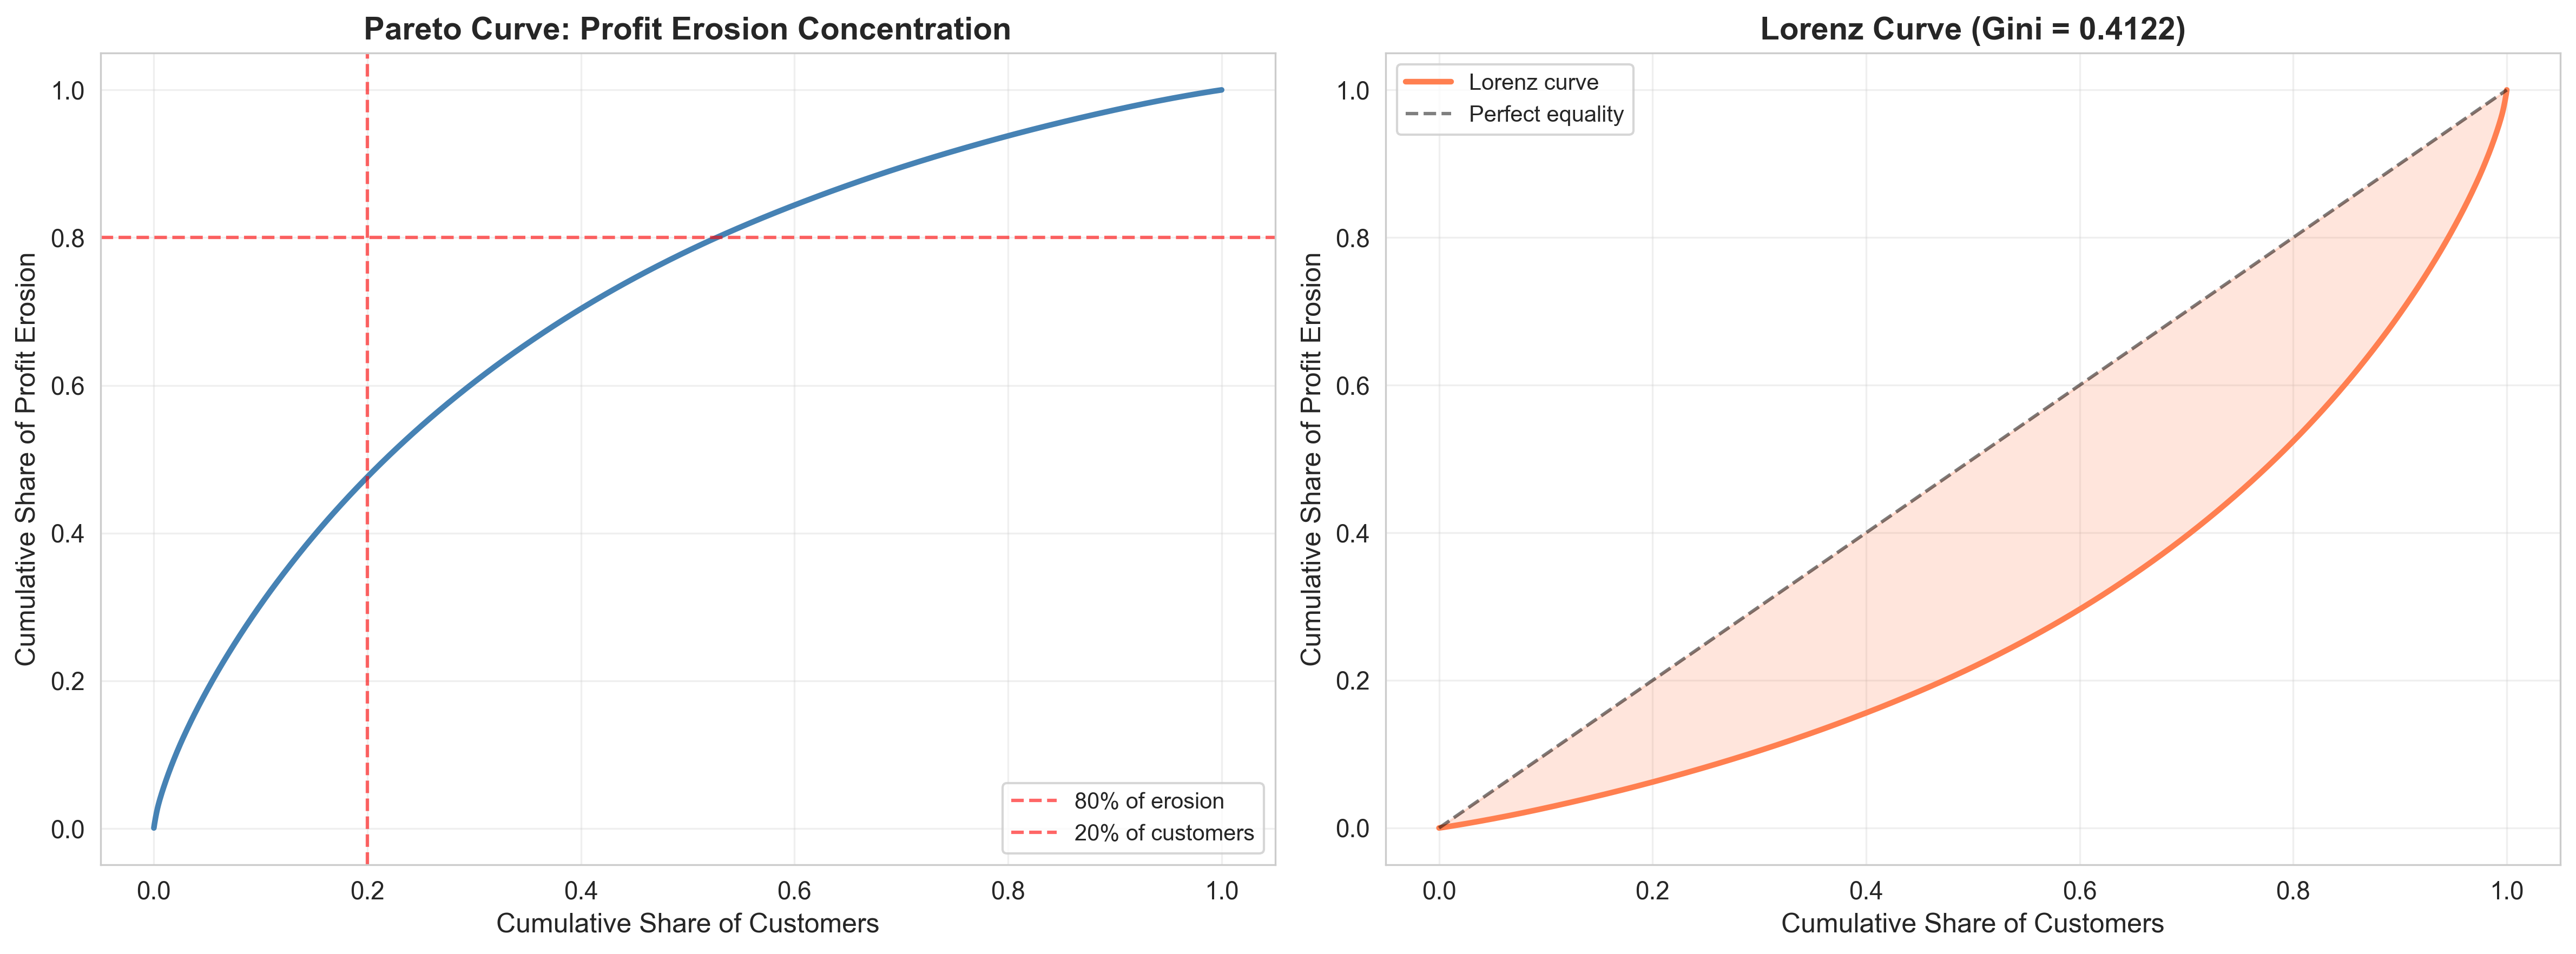

In [22]:
from IPython.display import Image, display

# Display concentration curves
print('\n' + '='*70)
print('CONCENTRATION ANALYSIS VISUALIZATIONS')
print('='*70)
display(Image(filename=str(fig_dir / 'concentration_curves.png')))


CLUSTERING DIAGNOSTICS


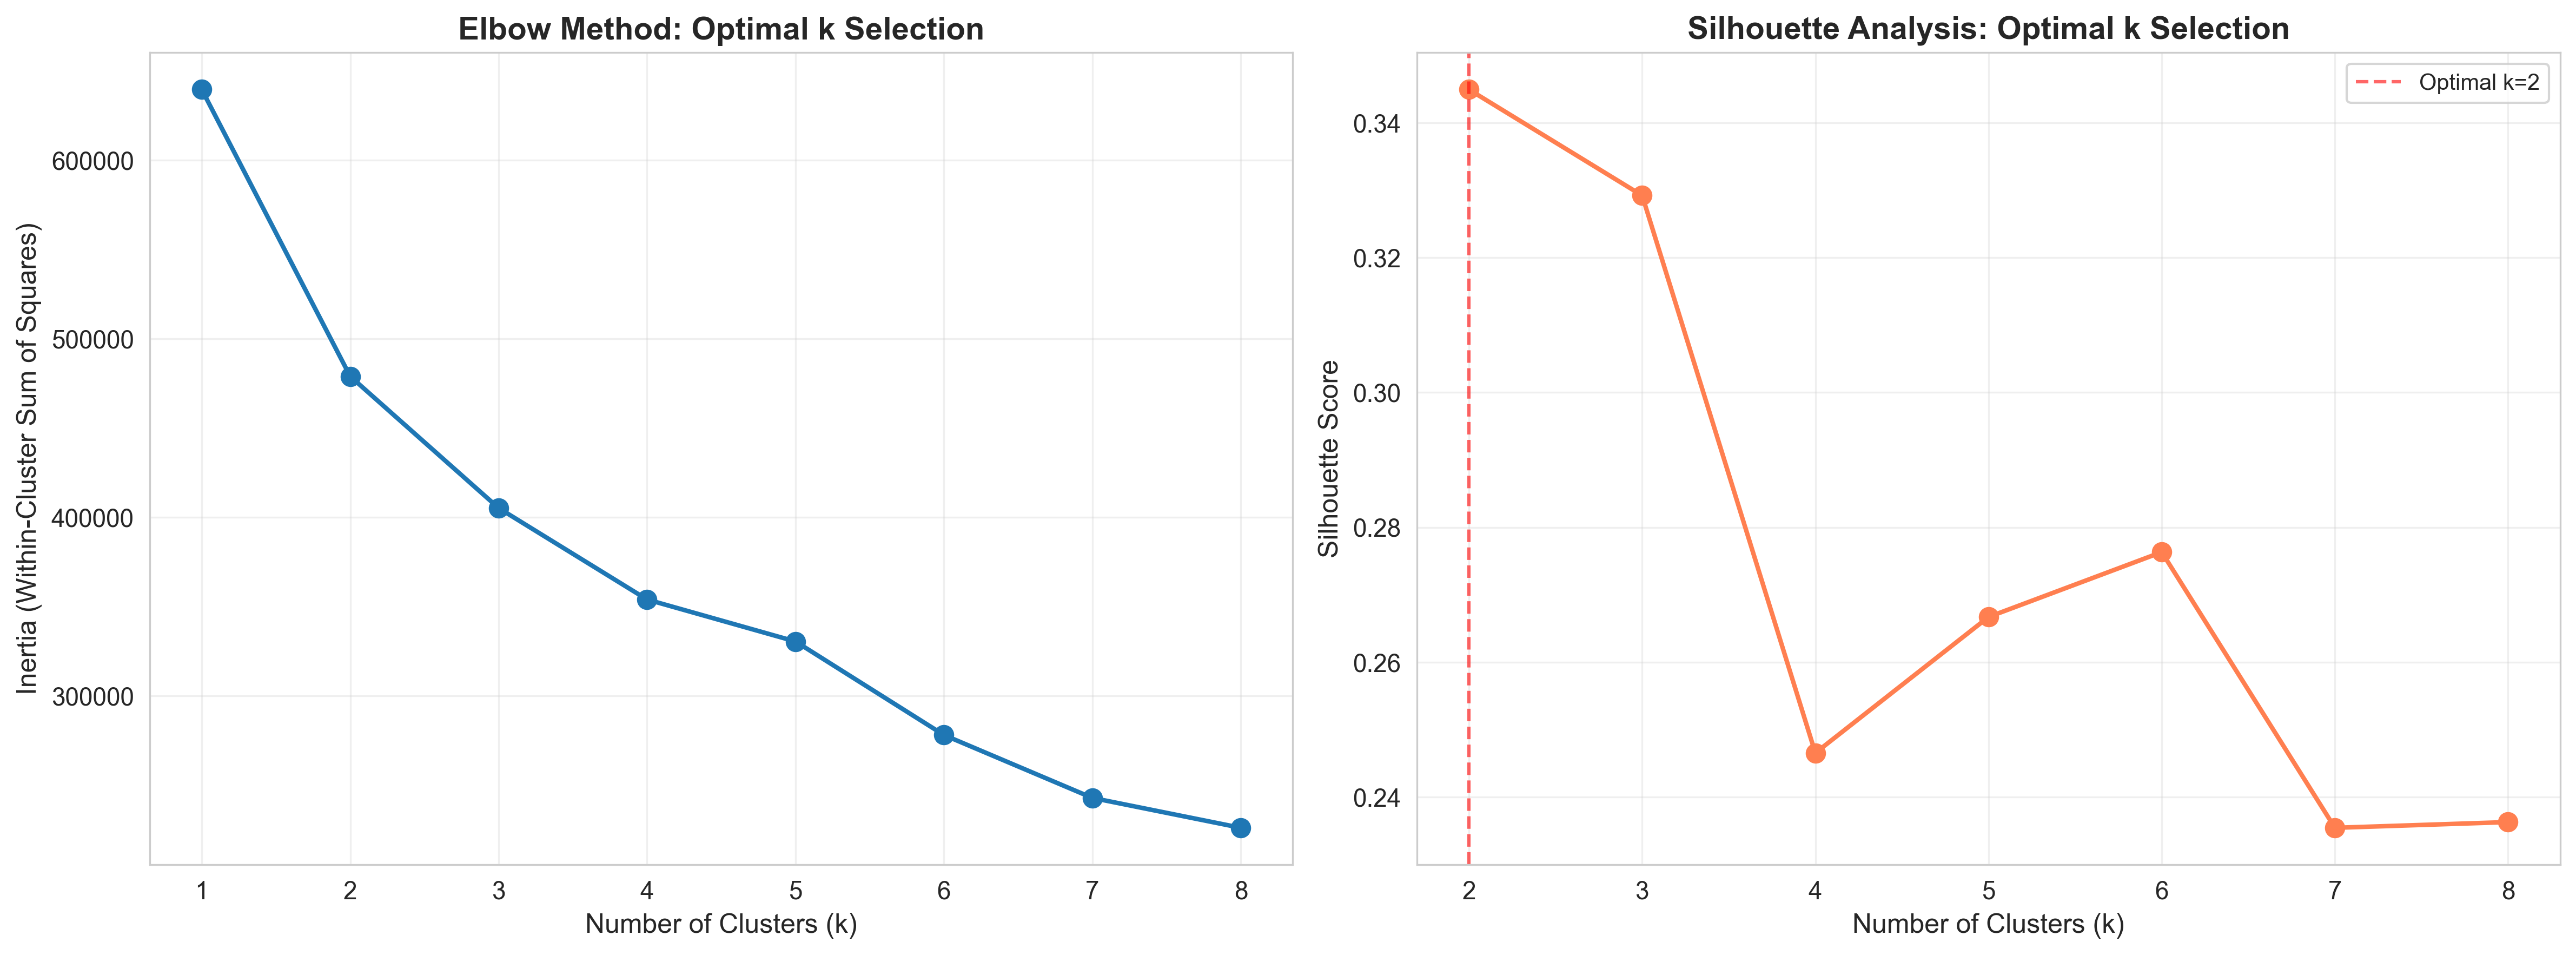

In [23]:
# Display clustering diagnostics
print('\n' + '='*70)
print('CLUSTERING DIAGNOSTICS')
print('='*70)
display(Image(filename=str(fig_dir / 'clustering_diagnostics.png')))


CLUSTER PROFILES


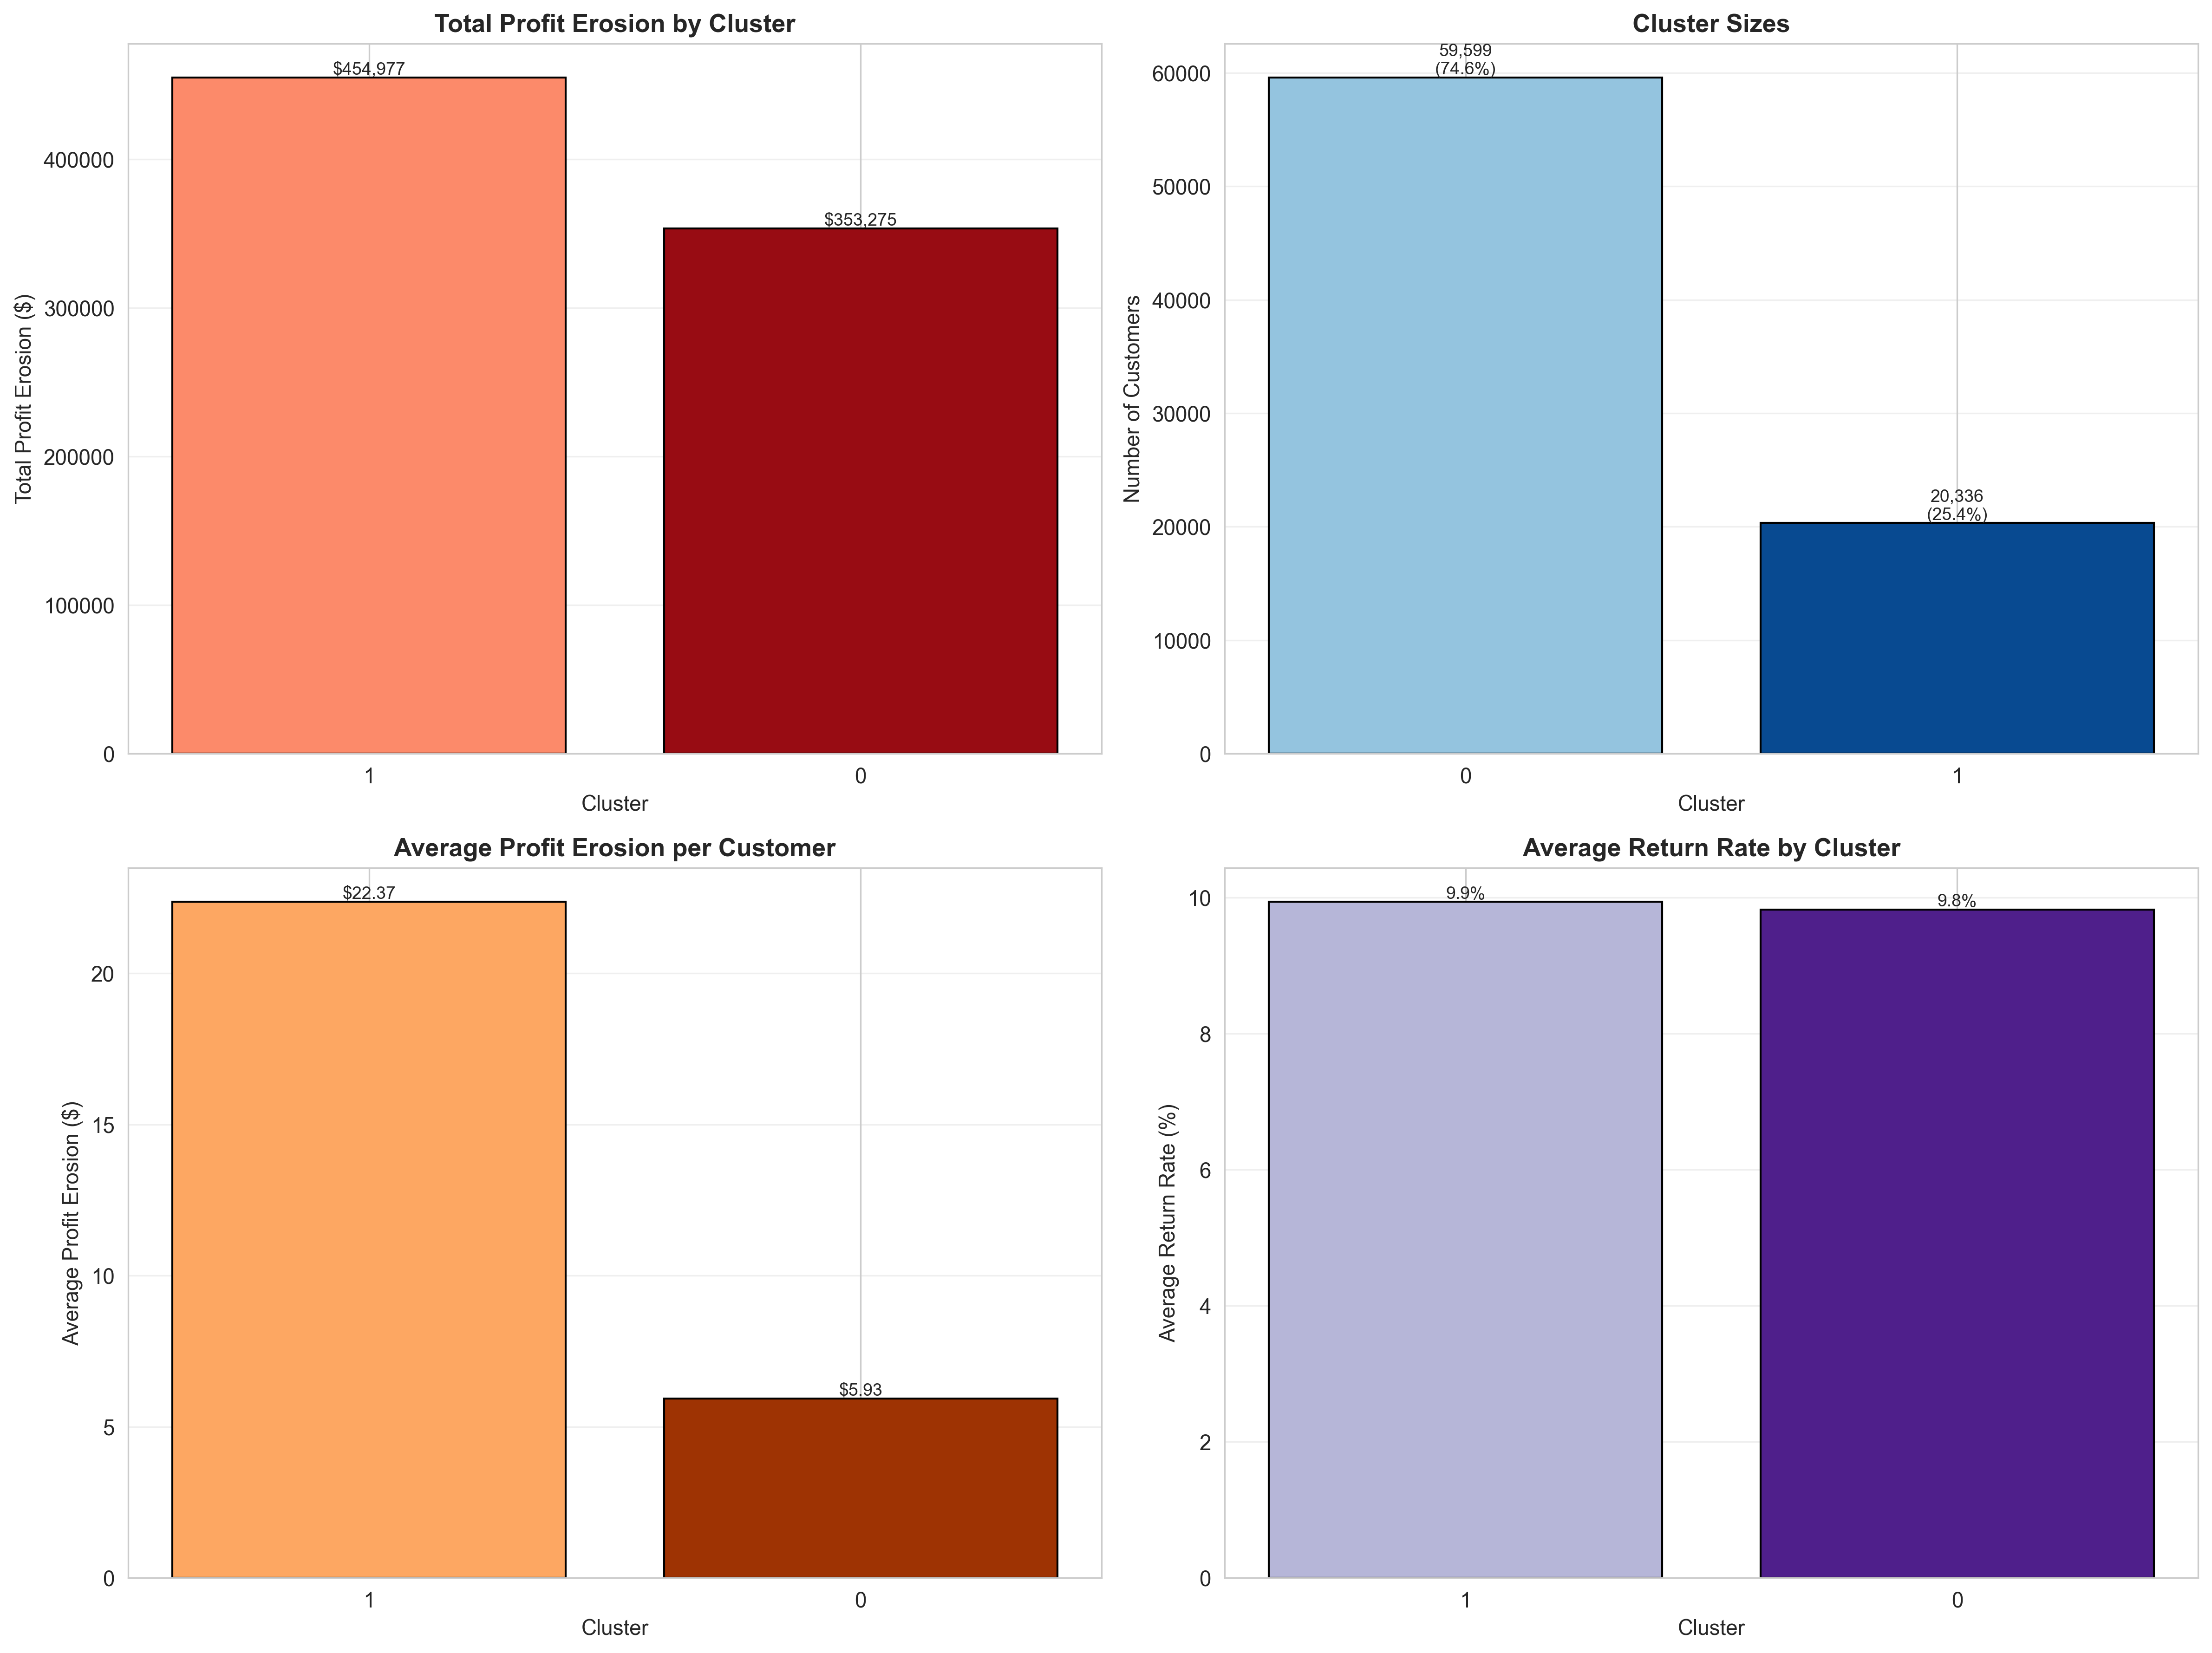

In [24]:
# Display cluster profiles
print('\n' + '='*70)
print('CLUSTER PROFILES')
print('='*70)
display(Image(filename=str(fig_dir / 'cluster_profiles.png')))

## 8. Business Insights and Recommendations

### Key Findings

1. **Concentration Analysis**:
   - Profit erosion shows significant concentration among a small subset of customers
   - The Gini coefficient quantifies the degree of inequality in the distribution
   - Statistical testing confirms this concentration is not due to random variation
   - The Pareto principle is evident in the customer-erosion relationship

2. **Customer Segmentation**:
   - K-Means clustering identified distinct customer segments with different behavioral profiles
   - Segments show statistically significant differences in profit erosion outcomes
   - Quality metrics (silhouette, Calinski-Harabasz, Davies-Bouldin) indicate stable clusters
   - Post-hoc analysis reveals specific pairwise differences between segments

### Recommended Actions

#### High-Risk Segment Management
1. **Proactive Intervention**:
   - Implement predictive models to identify customers likely to migrate to high-erosion segments
   - Deploy targeted communications before first return (e.g., sizing guides, product details)
   - Consider differential return policies or restocking fees for repeat offenders

2. **Product Recommendations**:
   - Steer high-return customers toward lower-return categories
   - Use collaborative filtering to recommend items with lower return rates
   - Highlight "final sale" or "low-return" products in their browsing experience

#### Low-Risk Segment Cultivation
1. **Acquisition Targeting**:
   - Build lookalike audiences based on low-erosion segment characteristics
   - Prioritize marketing spend on channels that attract similar customers
   - Test messaging that emphasizes values aligned with this segment

2. **Retention & Loyalty**:
   - Reward low-return behavior with early access, discounts, or loyalty points
   - Create VIP programs specifically for customers in favorable segments
   - Use their feedback for product development and quality improvements

#### Operational Optimization
1. **Resource Allocation**:
   - Scale customer support and QA resources proportionally to segment risk
   - Implement segment-specific return inspection and processing workflows
   - Adjust inventory replenishment based on segment-specific return patterns

2. **Continuous Monitoring**:
   - Track segment composition and migration patterns monthly
   - Re-estimate clustering quarterly to capture evolving customer behaviors
   - Monitor concentration metrics (Gini, top-x shares) as KPIs
   - Set up alerts for customers transitioning between segments

### Next Steps

1. **Deep Dive Analysis**: Conduct qualitative research (surveys, interviews) with customers in each segment to understand behavioral drivers
2. **A/B Testing**: Pilot targeted interventions with high-erosion segments and measure impact
3. **Predictive Modeling**: Build classification models to predict segment membership for new customers
4. **Policy Design**: Develop segment-specific return policies in consultation with legal and customer experience teams
5. **Dashboard Development**: Create real-time monitoring dashboards for segment health metrics